In [1]:
# ── CELDA 0: Celda de verificación — corre esto primero
import numpy as np
import pandas as pd
import matplotlib
import sklearn
import xgboost as xgb
import shap

print(f"NumPy:      {np.__version__}")       # debe ser 1.26.x
print(f"pandas:     {pd.__version__}")       # debe ser 2.x
print(f"matplotlib: {matplotlib.__version__}")
print(f"sklearn:    {sklearn.__version__}")
print(f"xgboost:    {xgb.__version__}")
print(f"shap:       {shap.__version__}")
print("\n✅ Todo OK — puedes continuar con el análisis")

NumPy:      2.4.6
pandas:     3.0.2
matplotlib: 3.10.9
sklearn:    1.8.0
xgboost:    3.2.0
shap:       0.51.0

✅ Todo OK — puedes continuar con el análisis


In [2]:
# ============================================================
#  JV Program – VLR México
#  Script 02: Modelado Predictivo — Capítulo 5
#  Ejecutar después de haber corrido Script 01 (ETL + EDA)
#  Requiere: dataset_WO_nivel.parquet generado en Script 01
# ============================================================
 
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection        import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model           import LogisticRegression
from sklearn.ensemble               import RandomForestClassifier
from sklearn.preprocessing          import StandardScaler, LabelEncoder
from sklearn.pipeline               import Pipeline
from sklearn.metrics                import (accuracy_score, precision_score, recall_score,
                                             f1_score, roc_auc_score, confusion_matrix,
                                             roc_curve, precision_recall_curve,
                                             ConfusionMatrixDisplay, classification_report)
from sklearn.impute                 import SimpleImputer
from sklearn.compose                import ColumnTransformer
from sklearn.preprocessing          import OneHotEncoder
from sklearn.base                   import clone
import xgboost as xgb
import shap
 
# Estilo corporativo
plt.rcParams.update({
    "font.family":        "Arial",
    "axes.titlesize":     12,
    "axes.labelsize":     10,
    "figure.dpi":         150,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
})
COLOR_CORP = "#2E75B6"
PALETTE    = ["#1a3a5c","#2E75B6","#4A90C4","#5B9BD5","#78B4E0","#9ECAE8"]
RANDOM_STATE = 42
 
print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "pyarrow", "fastparquet", "-q"])
print("✅ Instalado — ahora vuelve a correr la Celda 2")

✅ Instalado — ahora vuelve a correr la Celda 2


In [4]:
# ── CELDA 2: Cargar dataset ────────────────────────────────────────────────────
import os

# FIX: inicializar dw=None explícitamente. La versión anterior solo
# definía `dw` dentro de los bloques if/elif que encuentran el archivo;
# si ninguno se cumplía, las celdas posteriores fallaban con NameError
# en lugar de mostrar el mensaje de error ya impreso aquí.
dw = None

if os.path.exists("dataset_WO_nivel.parquet"):
    try:
        dw = pd.read_parquet("dataset_WO_nivel.parquet")
        print("✅ Cargado desde Parquet")
    except ImportError:
        dw = pd.read_csv("dataset_WO_nivel.csv")
        print("✅ Cargado desde CSV (pyarrow no disponible)")
elif os.path.exists("dataset_WO_nivel.csv"):
    dw = pd.read_csv("dataset_WO_nivel.csv")
    print("✅ Cargado desde CSV")
else:
    print("❌ No se encontró el dataset")
    print("   Verifica que estés en la misma carpeta donde guardaste el archivo")
    print(f"   Carpeta actual: {os.getcwd()}")
    print(f"   Archivos disponibles: {os.listdir('.')}")

# FIX: detener la ejecución del notebook aquí si no se pudo cargar el
# dataset, en lugar de dejar que las celdas siguientes fallen con
# errores confusos sobre `dw` indefinido.
if dw is None:
    raise FileNotFoundError(
        "No se pudo cargar dataset_WO_nivel.parquet/csv. "
        "Ejecuta primero 01_ETL_JVProgram.ipynb."
    )

# Convertir fechas que pueden haber quedado como string en el CSV
cols_fecha = [c for c in dw.columns if "FECHA" in c or "DATE" in c or "SCHEDULE" in c]
for col in cols_fecha:
    dw[col] = pd.to_datetime(dw[col], errors="coerce")

print(f"\n✅ Dataset: {dw.shape[0]:,} WO × {dw.shape[1]} columnas")
print(f"   ES_RECHAZADA: {dw['ES_RECHAZADA'].value_counts().to_dict()}")


✅ Cargado desde Parquet

✅ Dataset: 44,485 WO × 48 columnas
   ES_RECHAZADA: {1: 43569, 0: 916}


In [5]:
# ── CELDA 3: Selección de features ───────────────────────────────────────────
# Features disponibles ANTES de la inspección QC (condición operativa real)
FEATURES_NUM = [
    "QTY",             # Cantidad planificada
    "TC_CORTE_H",      # Tiempo ciclo corte
    "TC_PREP_H",       # Tiempo ciclo preparación
    "TC_COSTURA_H",    # Tiempo ciclo costura
    "EFIC_CORTE",      # Eficiencia corte vs estándar
    "EFIC_PREP",       # Eficiencia preparación vs estándar
    "EFIC_COSTURA",    # Eficiencia costura vs estándar
    "CARGA_SEMANA",    # Carga de trabajo de la semana
    "SEMANA_NUM",      # Semana de producción (ordinal)
    "DIA_INICIO",      # Día de la semana de inicio
]
FEATURES_CAT = [
    "ITEM",            # Estilo del producto
    "BODY_PILLOW",     # Tipo de pieza
    "FAMILY",          # Familia de producto
]
TARGET = "ES_RECHAZADA"
 
# Filtrar solo columnas que existen
FEATURES_NUM = [f for f in FEATURES_NUM if f in dw.columns]
FEATURES_CAT = [f for f in FEATURES_CAT if f in dw.columns]
ALL_FEATURES = FEATURES_NUM + FEATURES_CAT
 
print(f"\n✅ Features numéricas ({len(FEATURES_NUM)}): {FEATURES_NUM}")
print(f"✅ Features categóricas ({len(FEATURES_CAT)}): {FEATURES_CAT}")

# Dataset de modelado: solo WO con QC completado
df_model = dw[ALL_FEATURES + [TARGET]].dropna(subset=[TARGET])
print(f"\n✅ Dataset de modelado: {len(df_model):,} WO con QC registrado")
print(f"   Clase 0 (Aprobadas):  {(df_model[TARGET]==0).sum():,} ({(df_model[TARGET]==0).mean()*100:.1f}%)")
print(f"   Clase 1 (Rechazadas): {(df_model[TARGET]==1).sum():,} ({(df_model[TARGET]==1).mean()*100:.1f}%)")
 
# Ratio de desbalance
ratio = (df_model[TARGET]==0).sum() / (df_model[TARGET]==1).sum()
print(f"\n   Ratio desbalance: {ratio:.1f}:1  ", end="")
print("→ Se aplicará class_weight='balanced'" if ratio > 3 else "→ Clases balanceadas")


✅ Features numéricas (10): ['QTY', 'TC_CORTE_H', 'TC_PREP_H', 'TC_COSTURA_H', 'EFIC_CORTE', 'EFIC_PREP', 'EFIC_COSTURA', 'CARGA_SEMANA', 'SEMANA_NUM', 'DIA_INICIO']
✅ Features categóricas (3): ['ITEM', 'BODY_PILLOW', 'FAMILY']

✅ Dataset de modelado: 44,485 WO con QC registrado
   Clase 0 (Aprobadas):  916 (2.1%)
   Clase 1 (Rechazadas): 43,569 (97.9%)

   Ratio desbalance: 0.0:1  → Clases balanceadas


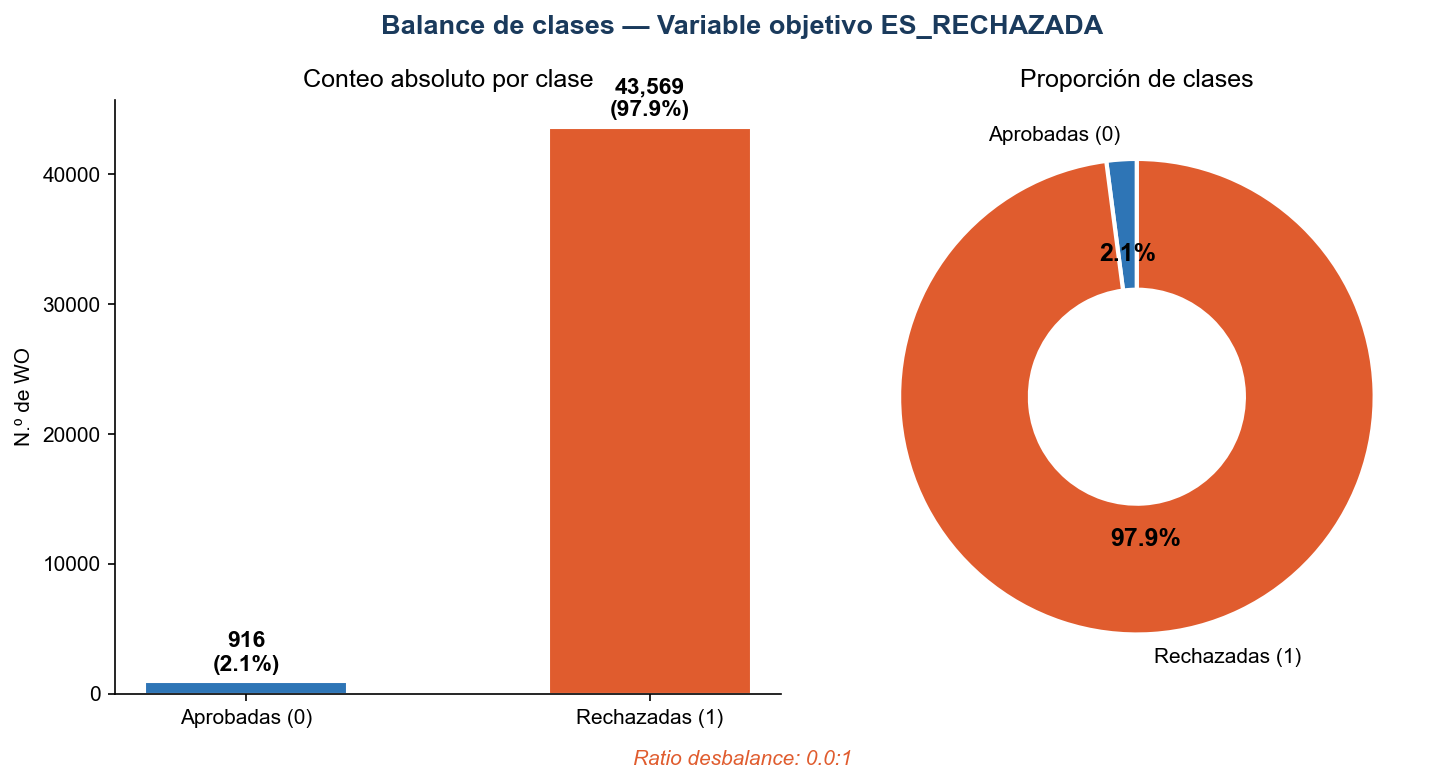

✅ Figura 14 guardada


In [6]:
# ── CELDA 4: FIGURA 14 — Balance de clases ────────────────────────────────────
clases = df_model[TARGET].value_counts().sort_index()
labels_c = ["Aprobadas (0)", "Rechazadas (1)"]
colors_c  = [COLOR_CORP, "#E05C2E"]
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Balance de clases — Variable objetivo ES_RECHAZADA",
             fontsize=13, fontweight="bold", color="#1a3a5c")
 
ax1.bar(labels_c, clases.values, color=colors_c, edgecolor="white", width=0.5)
for i, v in enumerate(clases.values):
    pct = v / clases.sum() * 100
    ax1.text(i, v + clases.max()*0.02, f"{v:,}\n({pct:.1f}%)",
             ha="center", fontsize=11, fontweight="bold")
ax1.set_ylabel("N.º de WO")
ax1.set_title("Conteo absoluto por clase")
 
wedges, texts, autotexts = ax2.pie(
    clases.values, labels=labels_c, colors=colors_c,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")
ax2.set_title("Proporción de clases")
 
nota = f"Ratio desbalance: {ratio:.1f}:1"
if ratio > 3:
    nota += "  →  Se aplicará class_weight='balanced'"
fig.text(0.5, -0.02, nota, ha="center", fontsize=10,
         color="#E05C2E", style="italic")
 
plt.tight_layout()
plt.savefig("figura14_balance_clases.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 14 guardada")

In [7]:
# ── CELDA 5: División train/test ──────────────────────────────────────────────
X = df_model[ALL_FEATURES]
y = df_model[TARGET]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.30,
    stratify     = y,
    random_state = RANDOM_STATE
)
 
print(f"✅ Train: {len(X_train):,} WO  |  Test: {len(X_test):,} WO")
print(f"   Train → Rechazadas: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"   Test  → Rechazadas: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

✅ Train: 31,139 WO  |  Test: 13,346 WO
   Train → Rechazadas: 30,498 (97.9%)
   Test  → Rechazadas: 13,071  (97.9%)


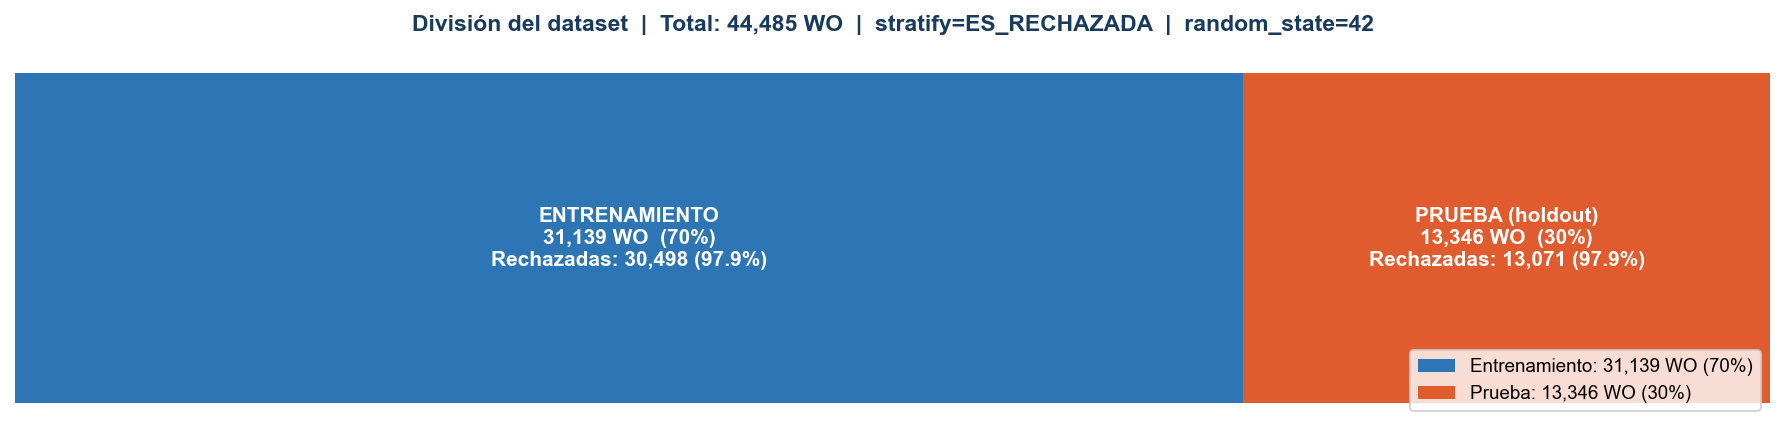

✅ Figura 17 guardada


In [8]:
# ── CELDA 6: FIGURA 17 — Diagrama división train/test ────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
 
total = len(df_model)
n_train, n_test = len(X_train), len(X_test)
 
# Barra principal
ax.barh(0, n_train, color=COLOR_CORP, height=0.5, label=f"Entrenamiento: {n_train:,} WO (70%)")
ax.barh(0, n_test, left=n_train, color="#E05C2E", height=0.5, label=f"Prueba: {n_test:,} WO (30%)")
 
ax.text(n_train/2, 0, f"ENTRENAMIENTO\n{n_train:,} WO  ({n_train/total*100:.0f}%)\nRechazadas: {y_train.sum():,} ({y_train.mean()*100:.1f}%)",
        ha="center", va="center", color="white", fontsize=10, fontweight="bold")
ax.text(n_train + n_test/2, 0, f"PRUEBA (holdout)\n{n_test:,} WO  ({n_test/total*100:.0f}%)\nRechazadas: {y_test.sum():,} ({y_test.mean()*100:.1f}%)",
        ha="center", va="center", color="white", fontsize=10, fontweight="bold")
 
ax.set_xlim(0, total)
ax.set_title(f"División del dataset  |  Total: {total:,} WO  |  "
             f"stratify=ES_RECHAZADA  |  random_state={RANDOM_STATE}",
             fontsize=11, fontweight="bold", color="#1a3a5c", pad=12)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("figura17_division_dataset.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 17 guardada")

In [9]:
# ── CELDA 7: Preprocesamiento ─────────────────────────────────────────────────
# Pipeline de preprocesamiento
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, FEATURES_NUM),
    ("cat", cat_pipeline, FEATURES_CAT),
], remainder="drop")

preprocessor.fit(X_train, y_train)

# Peso de clases para compensar desbalance
cw = "balanced" if ratio > 3 else None
scale_pos = ratio if ratio > 3 else 1.0
print(f"✅ class_weight='{cw}'  |  scale_pos_weight XGB={scale_pos:.1f}")

# Verificación de consistencia: número de columnas tras la transformación
n_cols_check = preprocessor.transform(X_train.iloc[[0]]).shape[1]
print(f"✅ Preprocessor fiteado una sola vez. Columnas generadas: {n_cols_check}")


✅ class_weight='None'  |  scale_pos_weight XGB=1.0
✅ Preprocessor fiteado una sola vez. Columnas generadas: 12718


In [10]:
# ── CELDA 8: Entrenamiento de los 3 modelos ───────────────────────────────────
print("\n🔄 Entrenando modelos con GridSearchCV (5-fold CV)...\n")

# ── Modelo 1: Regresión Logística ─────────────────────────────────────────────

pipe_rl = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=100, random_state=RANDOM_STATE,
                               class_weight=cw))
])
param_rl = {
    "clf__C":       [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver":  ["lbfgs"],
}
gs_rl = GridSearchCV(pipe_rl, param_rl, cv=StratifiedKFold(5),
                     scoring="roc_auc", n_jobs=-1, verbose=0)
gs_rl.fit(X_train, y_train)
print(f"✅ Regresión Logística  | Mejor AUC-CV: {gs_rl.best_score_:.4f} | "
      f"Params: {gs_rl.best_params_}")

# ── Modelo 2: Random Forest ───────────────────────────────────────────────────
pipe_rf = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, class_weight=cw,
                                   n_jobs=-1))
])
param_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth":    [None, 8, 15],
    "clf__min_samples_split": [2, 5],
}
gs_rf = GridSearchCV(pipe_rf, param_rf, cv=StratifiedKFold(5),
                     scoring="roc_auc", n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
print(f"✅ Random Forest        | Mejor AUC-CV: {gs_rf.best_score_:.4f} | "
      f"Params: {gs_rf.best_params_}")

# ── Modelo 3: XGBoost ─────────────────────────────────────────────────────────

X_train_t_arr = preprocessor.transform(X_train)
X_test_t_arr  = preprocessor.transform(X_test)

feature_names_xgb = preprocessor.get_feature_names_out()
X_train_t = pd.DataFrame(X_train_t_arr, columns=feature_names_xgb, index=X_train.index)
X_test_t  = pd.DataFrame(X_test_t_arr,  columns=feature_names_xgb, index=X_test.index)

print(f"✅ X_train_t: {X_train_t.shape}  |  X_test_t: {X_test_t.shape}")

param_xgb = {
    "n_estimators":    [100, 200],
    "max_depth":       [3, 5, 7],
    "learning_rate":   [0.05, 0.1],
    "subsample":       [0.8, 1.0],
    "scale_pos_weight":[scale_pos],
}
xgb_clf = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric="auc",
                              verbosity=0)
gs_xgb = GridSearchCV(xgb_clf, param_xgb, cv=StratifiedKFold(5),
                      scoring="roc_auc", n_jobs=-1, verbose=0)
gs_xgb.fit(X_train_t, y_train)
print(f"✅ XGBoost              | Mejor AUC-CV: {gs_xgb.best_score_:.4f} | "
      f"Params: {gs_xgb.best_params_}")
print(f"✅ Features que ve el modelo XGBoost entrenado: "
      f"{gs_xgb.best_estimator_.n_features_in_}")



🔄 Entrenando modelos con GridSearchCV (5-fold CV)...

✅ Regresión Logística  | Mejor AUC-CV: 0.9489 | Params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
✅ Random Forest        | Mejor AUC-CV: 0.9902 | Params: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
✅ X_train_t: (31139, 12718)  |  X_test_t: (13346, 12718)
✅ XGBoost              | Mejor AUC-CV: 0.9922 | Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'scale_pos_weight': 1.0, 'subsample': 0.8}
✅ Features que ve el modelo XGBoost entrenado: 12718


In [11]:
# ── CELDA 9: TABLA 18 — Métricas en conjunto de prueba ───────────────────────
def evaluar(nombre, modelo, X_te, y_te, usa_pipeline=True):
    """Calcula todas las métricas sobre el conjunto de prueba."""
    if usa_pipeline:
        y_pred  = modelo.predict(X_te)
        y_proba = modelo.predict_proba(X_te)[:,1]
    else:
        y_pred  = modelo.predict(X_te)
        y_proba = modelo.predict_proba(X_te)[:,1]
    return {
        "Modelo":     nombre,
        "Accuracy":   round(accuracy_score(y_te, y_pred),    4),
        "Precision":  round(precision_score(y_te, y_pred, zero_division=0), 4),
        "Recall":     round(recall_score(y_te, y_pred,    zero_division=0), 4),
        "F1-Score":   round(f1_score(y_te, y_pred,        zero_division=0), 4),
        "AUC-ROC":    round(roc_auc_score(y_te, y_proba),    4),
        "_y_pred":    y_pred,
        "_y_proba":   y_proba,
    }
 
res_rl  = evaluar("Regresión Logística",  gs_rl.best_estimator_, X_test,   y_test)
res_rf  = evaluar("Random Forest",        gs_rf.best_estimator_, X_test,   y_test)
res_xgb = evaluar("XGBoost",              gs_xgb.best_estimator_, X_test_t, y_test, usa_pipeline=False)
 
resultados = [res_rl, res_rf, res_xgb]
cols_tabla  = ["Modelo","Accuracy","Precision","Recall","F1-Score","AUC-ROC"]
df_metricas = pd.DataFrame(resultados)[cols_tabla]
 
print("\n" + "="*70)
print("TABLA 18 — Métricas en conjunto de prueba (copiar al documento Word)")
print("="*70)
print(df_metricas.to_string(index=False))
 
# Identificar mejor modelo por AUC-ROC
mejor_idx   = df_metricas["AUC-ROC"].idxmax()
mejor_nombre = df_metricas.loc[mejor_idx, "Modelo"]
print(f"\n🏆 Mejor modelo: {mejor_nombre} (AUC-ROC = {df_metricas.loc[mejor_idx,'AUC-ROC']})")
 


TABLA 18 — Métricas en conjunto de prueba (copiar al documento Word)
             Modelo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística    0.9775     0.9818  0.9955    0.9886   0.9579
      Random Forest    0.9900     0.9907  0.9992    0.9949   0.9862
            XGBoost    0.9913     0.9945  0.9966    0.9956   0.9913

🏆 Mejor modelo: XGBoost (AUC-ROC = 0.9913)


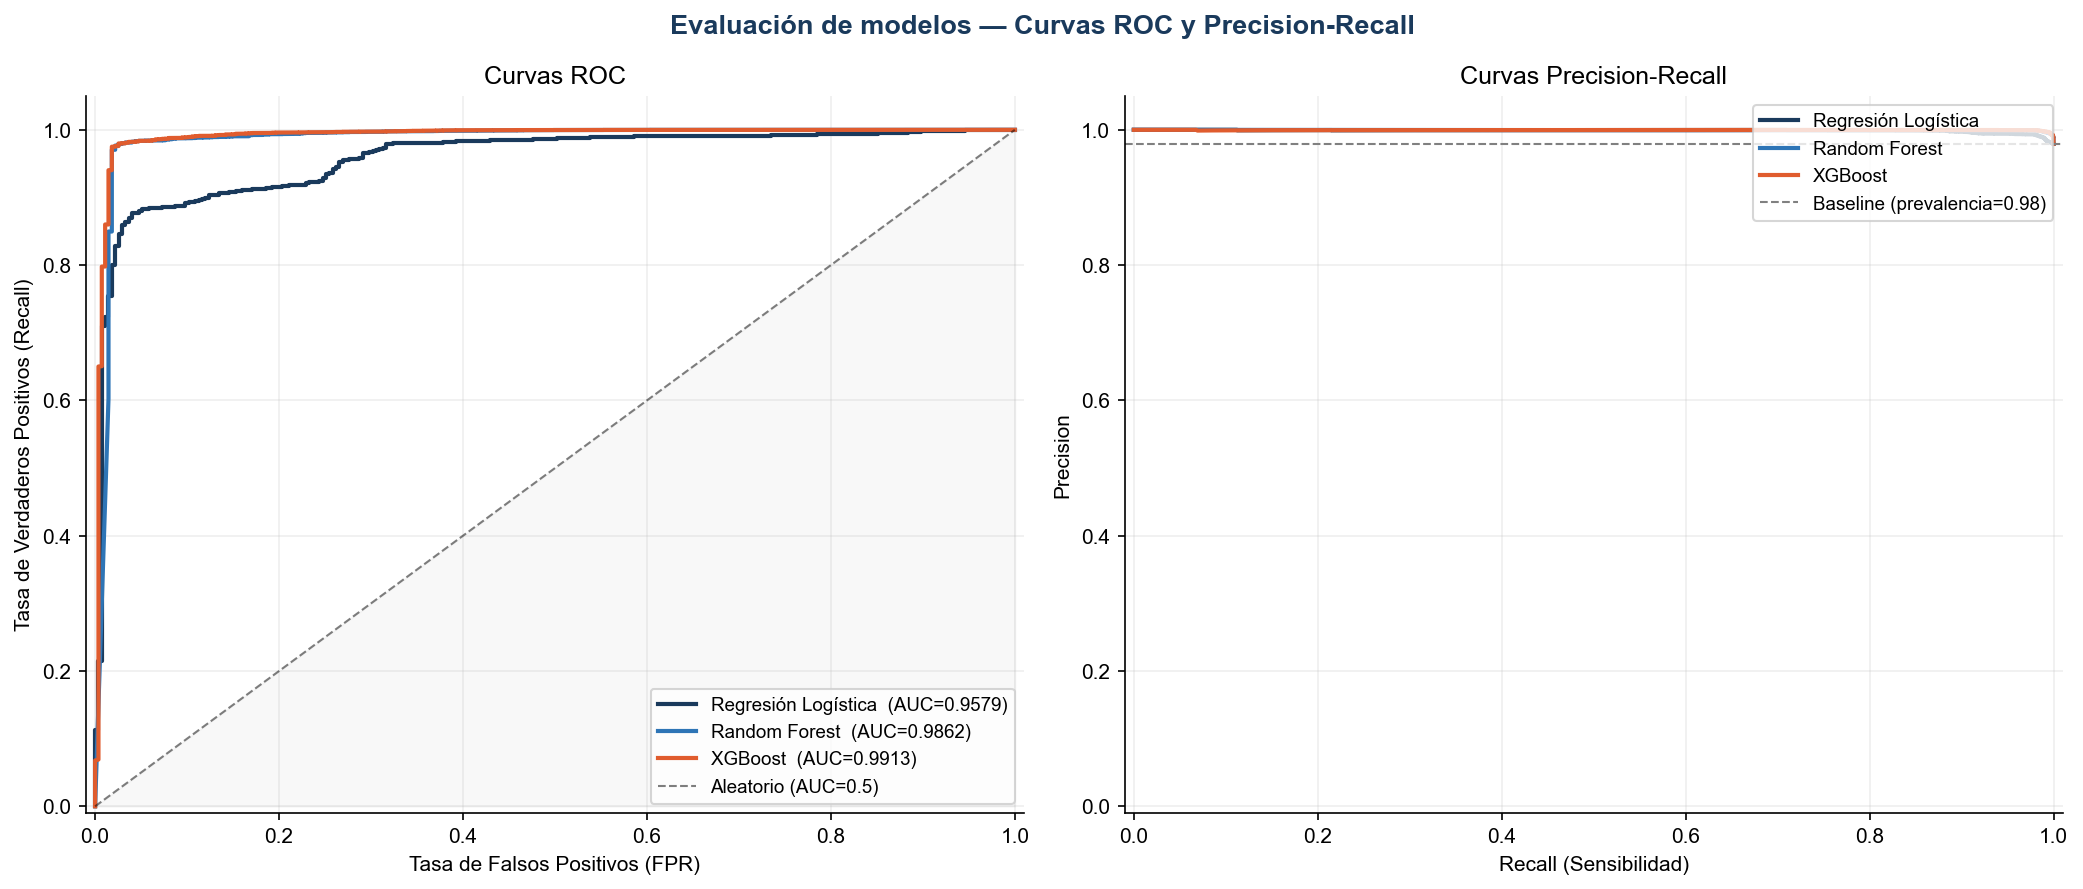

✅ Figura 19 guardada


In [12]:
# ── CELDA 10: FIGURA 19 — Curvas ROC + Precision-Recall ──────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Evaluación de modelos — Curvas ROC y Precision-Recall",
             fontsize=13, fontweight="bold", color="#1a3a5c")
 
colores = [PALETTE[0], PALETTE[1], "#E05C2E"]
modelos_plot = [
    ("Regresión Logística", res_rl["_y_proba"]),
    ("Random Forest",       res_rf["_y_proba"]),
    ("XGBoost",             res_xgb["_y_proba"]),
]
 
# Curvas ROC
for (nombre, proba), color in zip(modelos_plot, colores):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{nombre}  (AUC={auc:.4f})")
 
ax1.plot([0,1],[0,1], "k--", linewidth=1, alpha=0.5, label="Aleatorio (AUC=0.5)")
ax1.fill_between([0,1],[0,1], alpha=0.05, color="gray")
ax1.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax1.set_ylabel("Tasa de Verdaderos Positivos (Recall)")
ax1.set_title("Curvas ROC")
ax1.legend(fontsize=9, loc="lower right")
ax1.set_xlim([-0.01, 1.01])
ax1.set_ylim([-0.01, 1.05])
ax1.grid(alpha=0.2)
 
# Curvas Precision-Recall
prevalencia = y_test.mean()
for (nombre, proba), color in zip(modelos_plot, colores):
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, color=color, linewidth=2, label=nombre)
 
ax2.axhline(prevalencia, color="gray", linestyle="--", linewidth=1,
            label=f"Baseline (prevalencia={prevalencia:.2f})")
ax2.set_xlabel("Recall (Sensibilidad)")
ax2.set_ylabel("Precision")
ax2.set_title("Curvas Precision-Recall")
ax2.legend(fontsize=9, loc="upper right")
ax2.set_xlim([-0.01, 1.01])
ax2.set_ylim([-0.01, 1.05])
ax2.grid(alpha=0.2)
 
plt.tight_layout()
plt.savefig("figura19_curvas_roc_pr.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 19 guardada")

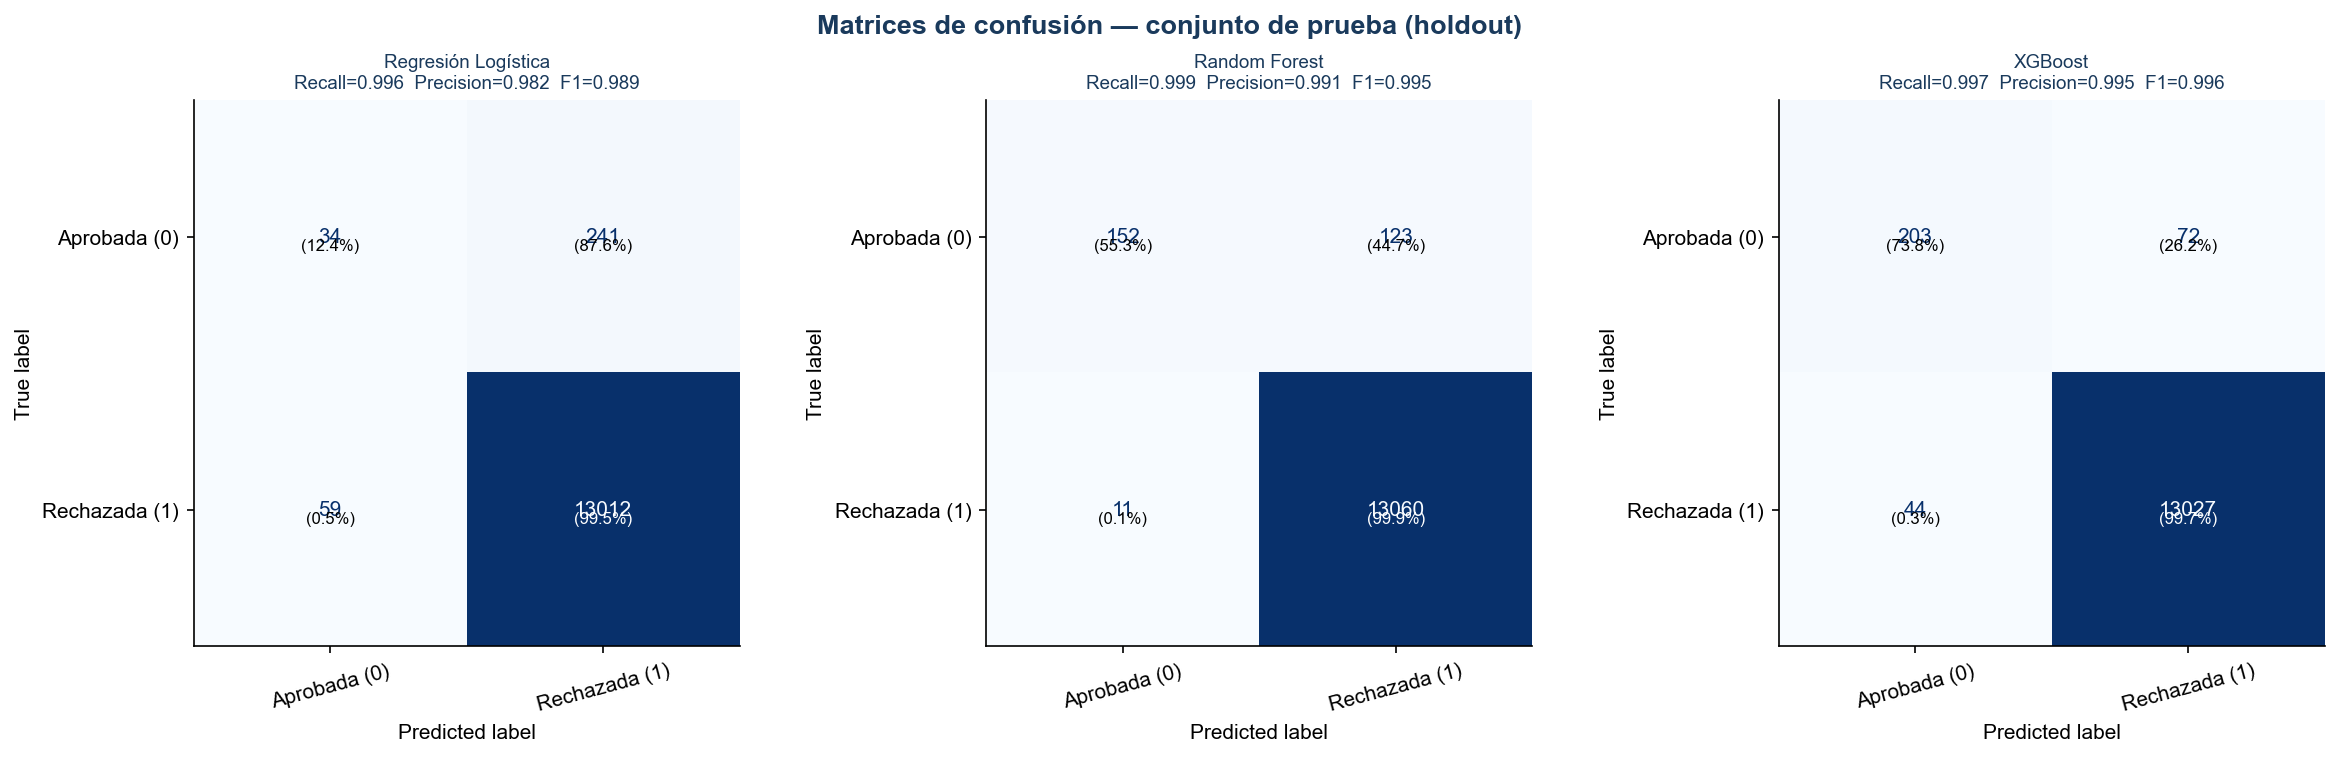

✅ Figura 20 guardada


In [13]:
# ── CELDA 11: FIGURA 20 — Matrices de confusión ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Matrices de confusión — conjunto de prueba (holdout)",
             fontsize=13, fontweight="bold", color="#1a3a5c")
 
modelos_cm = [
    ("Regresión Logística", res_rl["_y_pred"],  res_rl),
    ("Random Forest",       res_rf["_y_pred"],  res_rf),
    ("XGBoost",             res_xgb["_y_pred"], res_xgb),
]
 
for ax, (nombre, y_pred, res) in zip(axes, modelos_cm):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Aprobada (0)","Rechazada (1)"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"{nombre}\n"
        f"Recall={res['Recall']:.3f}  Precision={res['Precision']:.3f}  F1={res['F1-Score']:.3f}",
        fontsize=9, color="#1a3a5c"
    )
    ax.tick_params(axis="x", rotation=15)
 
    # Añadir porcentajes en cada celda
    total_real = cm.sum(axis=1, keepdims=True)
    cm_pct = cm / total_real * 100
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"\n({cm_pct[i,j]:.1f}%)",
                    ha="center", va="center", fontsize=8,
                    color="white" if cm[i,j] > cm.max()/2 else "black")
 
plt.tight_layout()
plt.savefig("figura20_matrices_confusion.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 20 guardada")

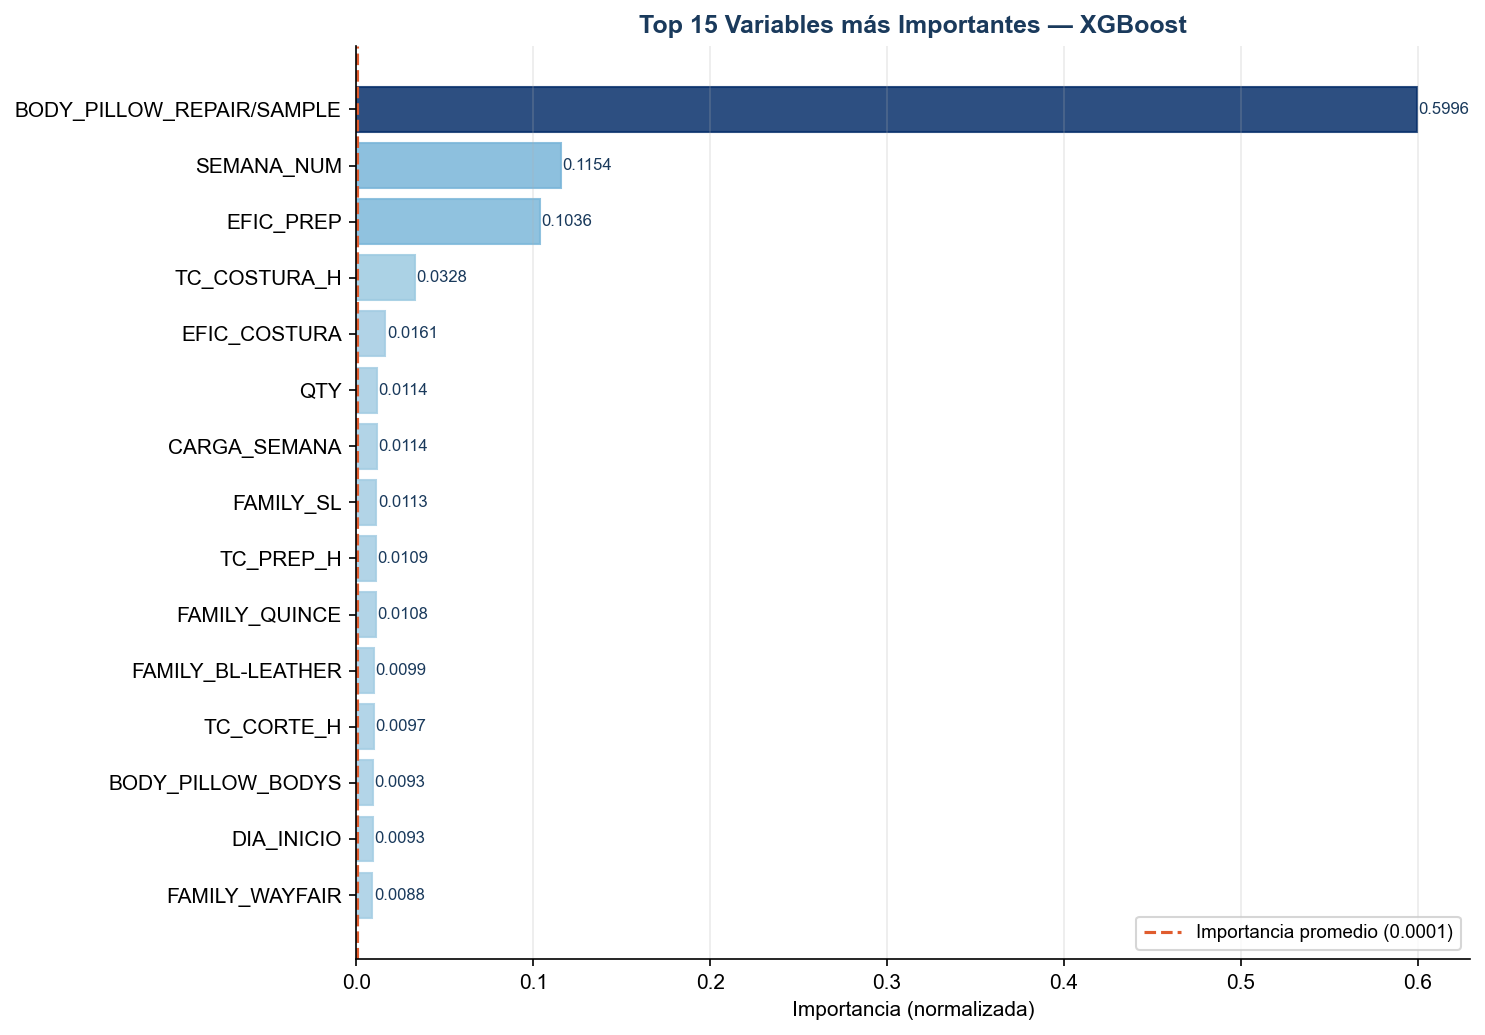

✅ Figura 21 guardada

📋 Top 10 variables más importantes:
                  Feature  Importancia
BODY_PILLOW_REPAIR/SAMPLE     0.599579
               SEMANA_NUM     0.115414
                EFIC_PREP     0.103577
             TC_COSTURA_H     0.032824
             EFIC_COSTURA     0.016127
                      QTY     0.011395
             CARGA_SEMANA     0.011389
                FAMILY_SL     0.011269
                TC_PREP_H     0.010856
            FAMILY_QUINCE     0.010767


In [14]:
# ── CELDA 12: FIGURA 21 — Importancia de variables ───────────────────────────
# Obtener nombres de features tras el preprocesamiento
try:
    cat_encoder = preprocessor.named_transformers_["cat"]["encoder"]
    cat_names   = cat_encoder.get_feature_names_out(FEATURES_CAT).tolist()
except Exception:
    cat_names = []
 
feature_names = FEATURES_NUM + cat_names
 
# Importancia según el mejor modelo
if mejor_nombre == "XGBoost":
    importancias = gs_xgb.best_estimator_.feature_importances_
elif mejor_nombre == "Random Forest":
    importancias = gs_rf.best_estimator_.named_steps["clf"].feature_importances_
else:  # Regresión Logística
    coef = np.abs(gs_rl.best_estimator_.named_steps["clf"].coef_[0])
    importancias = coef / coef.sum()
 
# Alinear longitudes
min_len = min(len(importancias), len(feature_names))
df_imp = (pd.DataFrame({
    "Feature":    feature_names[:min_len],
    "Importancia": importancias[:min_len]
})
.sort_values("Importancia", ascending=True)
.tail(15))
 
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_imp["Feature"], df_imp["Importancia"],
               color=COLOR_CORP, alpha=0.85, edgecolor="white")
 
# Gradiente de color por importancia
norm = plt.Normalize(df_imp["Importancia"].min(), df_imp["Importancia"].max())
cmap = plt.cm.Blues
for bar, val in zip(bars, df_imp["Importancia"]):
    bar.set_color(cmap(0.35 + norm(val) * 0.65))
 
# Etiquetas de valor
for bar, val in zip(bars, df_imp["Importancia"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8, color="#1a3a5c")
 
prom = importancias[:min_len].mean()
ax.axvline(prom, color="#E05C2E", linestyle="--", linewidth=1.5,
           label=f"Importancia promedio ({prom:.4f})")
ax.set_xlabel("Importancia (normalizada)")
ax.set_title(f"Top 15 Variables más Importantes — {mejor_nombre}",
             fontsize=12, fontweight="bold", color="#1a3a5c")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.savefig("figura21_importancia_variables.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 21 guardada")
 
print("\n📋 Top 10 variables más importantes:")
print(df_imp.tail(10).sort_values("Importancia", ascending=False).to_string(index=False))


🔄 Calculando valores SHAP (puede tomar 1-2 minutos)...


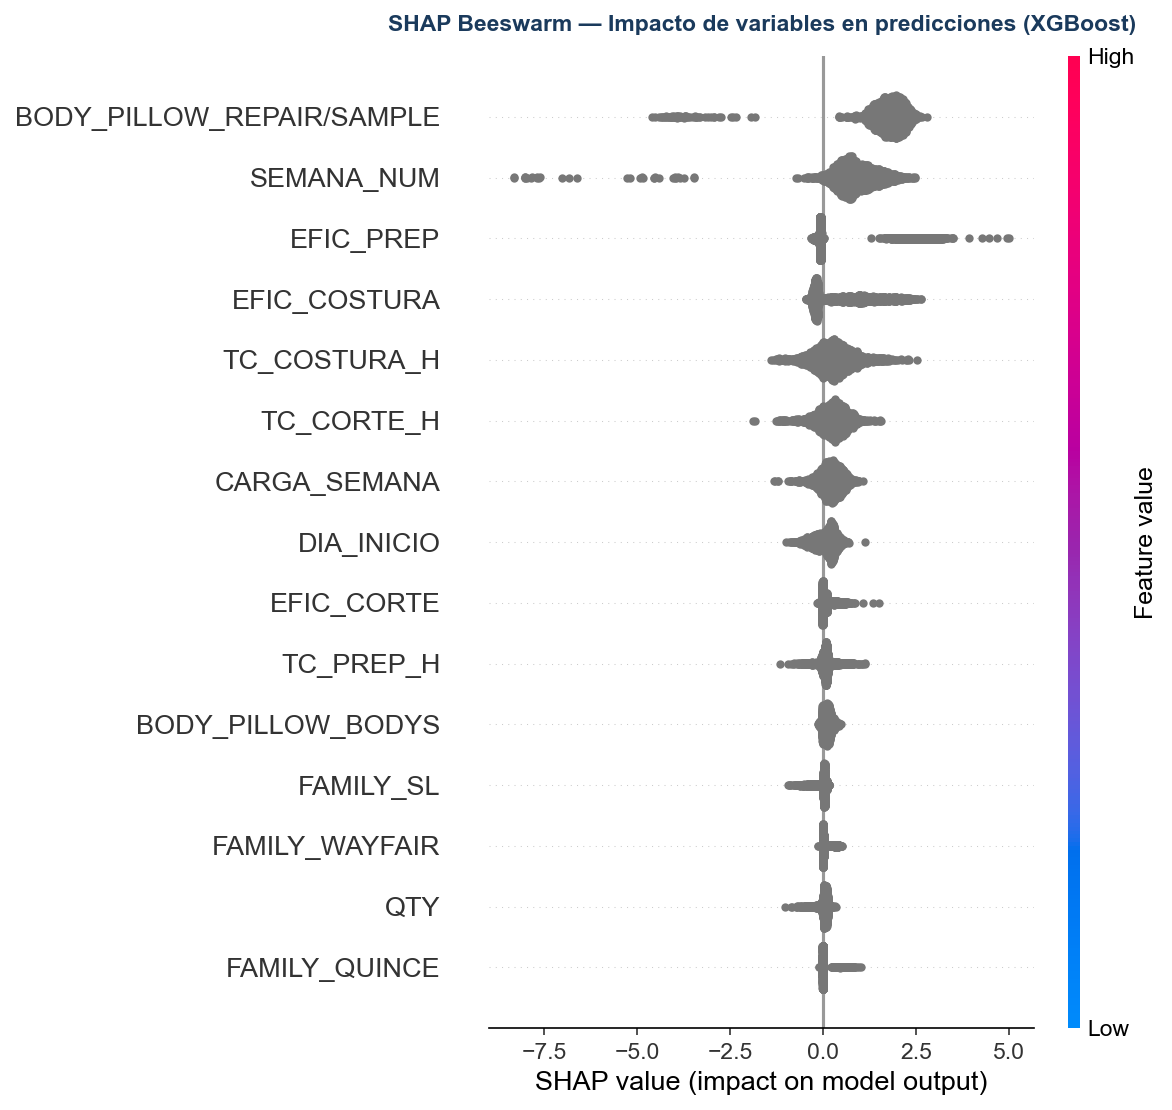

✅ Figura 22 guardada


In [15]:
# ── CELDA 13: FIGURA 22 — SHAP Beeswarm ──────────────────────────────────────
print("\n🔄 Calculando valores SHAP (puede tomar 1-2 minutos)...")
 
# Usar el mejor modelo con datos ya preprocesados
if mejor_nombre == "XGBoost":
    modelo_shap  = gs_xgb.best_estimator_
    X_shap       = X_test_t
else:
    # Para RF o RL, extraer el estimador del pipeline y transformar
    modelo_shap  = (gs_rf if mejor_nombre == "Random Forest" else gs_rl).best_estimator_.named_steps["clf"]
    X_shap       = (gs_rf if mejor_nombre == "Random Forest" else gs_rl).best_estimator_.named_steps["pre"].transform(X_test)
 
# Muestra representativa para SHAP (máx 2000 filas para velocidad)
n_shap  = min(2000, len(X_shap))
idx_shap = np.random.RandomState(RANDOM_STATE).choice(len(X_shap), n_shap, replace=False)
X_shap_sample = X_shap[idx_shap] if isinstance(X_shap, np.ndarray) else X_shap.iloc[idx_shap]
 
if mejor_nombre == "XGBoost":
    explainer   = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_shap_sample)
else:
    explainer   = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_shap_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # clase positiva
 
# Beeswarm plot
shap_df = pd.DataFrame(X_shap_sample, columns=feature_names[:X_shap_sample.shape[1]])
fig, ax = plt.subplots(figsize=(11, 7))
shap.summary_plot(shap_values, shap_df, plot_type="dot",
                  max_display=15, show=False, color_bar=True)
plt.title(f"SHAP Beeswarm — Impacto de variables en predicciones ({mejor_nombre})",
          fontsize=11, fontweight="bold", color="#1a3a5c", pad=12)
plt.tight_layout()
plt.savefig("figura22_shap_beeswarm.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 22 guardada")


🔍 WO de mayor riesgo predicho:
   Probabilidad de rechazo: 1.0000
   Resultado real:          RECHAZADA ✅


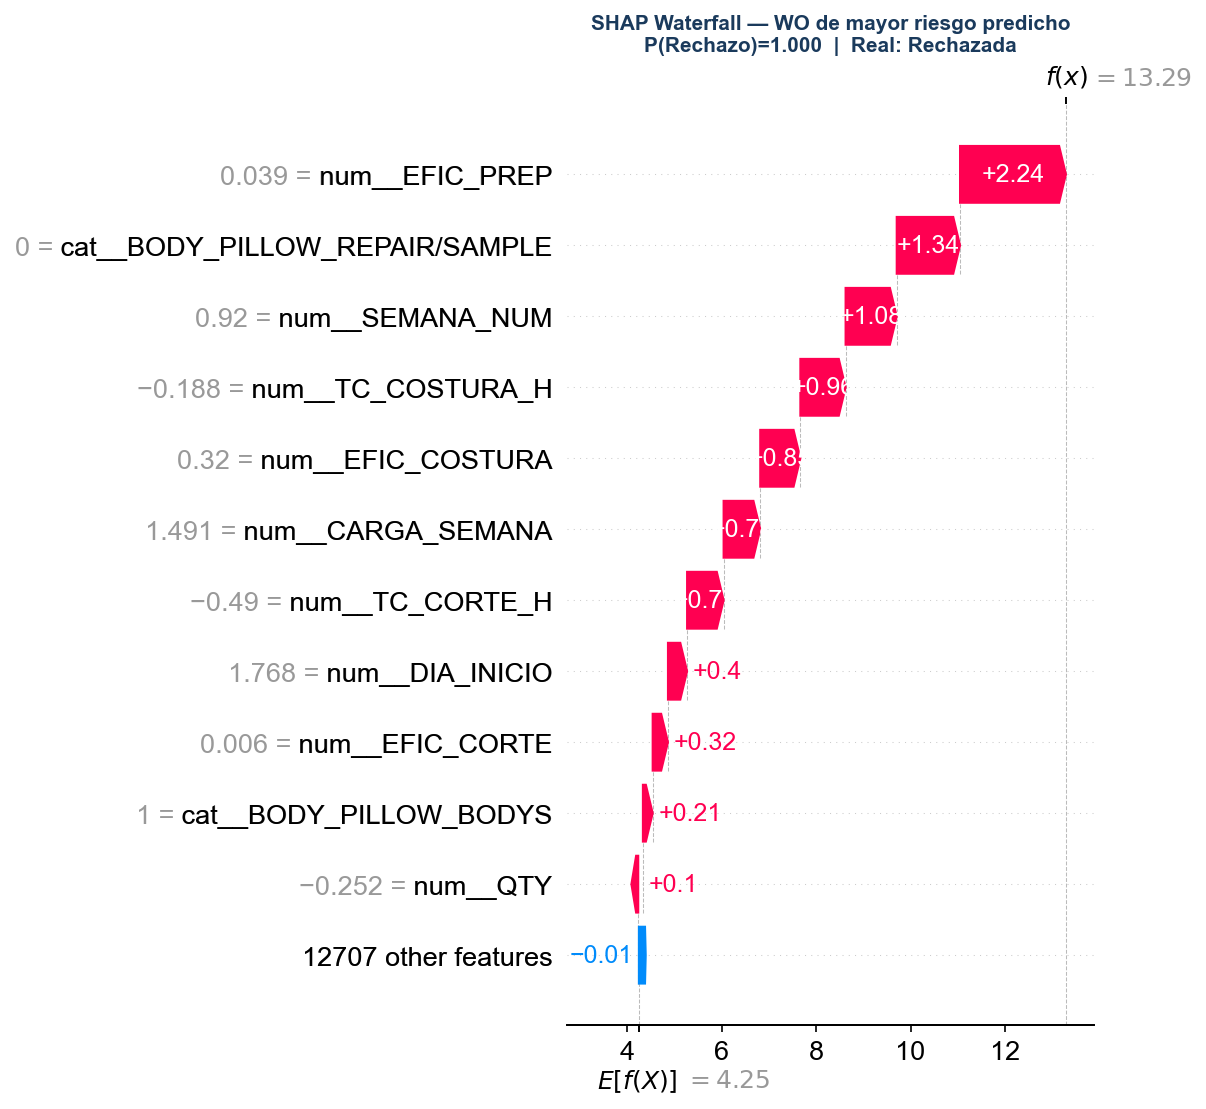

✅ Figura 23 guardada


In [16]:
# ── CELDA 14: FIGURA 23 — SHAP Waterfall (WO de mayor riesgo) ────────────────
# Encontrar la WO del conjunto de prueba con mayor probabilidad de rechazo
if mejor_nombre == "XGBoost":
    probas_test = gs_xgb.best_estimator_.predict_proba(X_test_t)[:,1]
else:
    probas_test = (gs_rf if mejor_nombre == "Random Forest"
                   else gs_rl).best_estimator_.predict_proba(X_test)[:,1]
 
idx_alto_riesgo = np.argmax(probas_test)
prob_max        = probas_test[idx_alto_riesgo]
real_label      = y_test.iloc[idx_alto_riesgo]
 
print(f"\n🔍 WO de mayor riesgo predicho:")
print(f"   Probabilidad de rechazo: {prob_max:.4f}")
print(f"   Resultado real:          {'RECHAZADA ✅' if real_label==1 else 'APROBADA (falso positivo)'}")
 
# Waterfall con SHAP Explanation object
if mejor_nombre == "XGBoost":
    explainer2 = shap.TreeExplainer(modelo_shap)
    X_single   = X_test_t[idx_alto_riesgo:idx_alto_riesgo+1]
else:
    X_single = X_shap_sample[idx_alto_riesgo:idx_alto_riesgo+1]
 
shap_single = explainer2(X_single)
if hasattr(shap_single, "values"):
    sv = shap_single[0] if len(shap_single.shape) == 1 else shap_single[0,:,1] if len(shap_single.shape) == 3 else shap_single[0]
 
fig, ax = plt.subplots(figsize=(11, 6))
shap.plots.waterfall(sv, max_display=12, show=False)
plt.title(f"SHAP Waterfall — WO de mayor riesgo predicho\n"
          f"P(Rechazo)={prob_max:.3f}  |  Real: {'Rechazada' if real_label==1 else 'Aprobada'}",
          fontsize=10, fontweight="bold", color="#1a3a5c")
plt.tight_layout()
plt.savefig("figura23_shap_waterfall.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Figura 23 guardada")

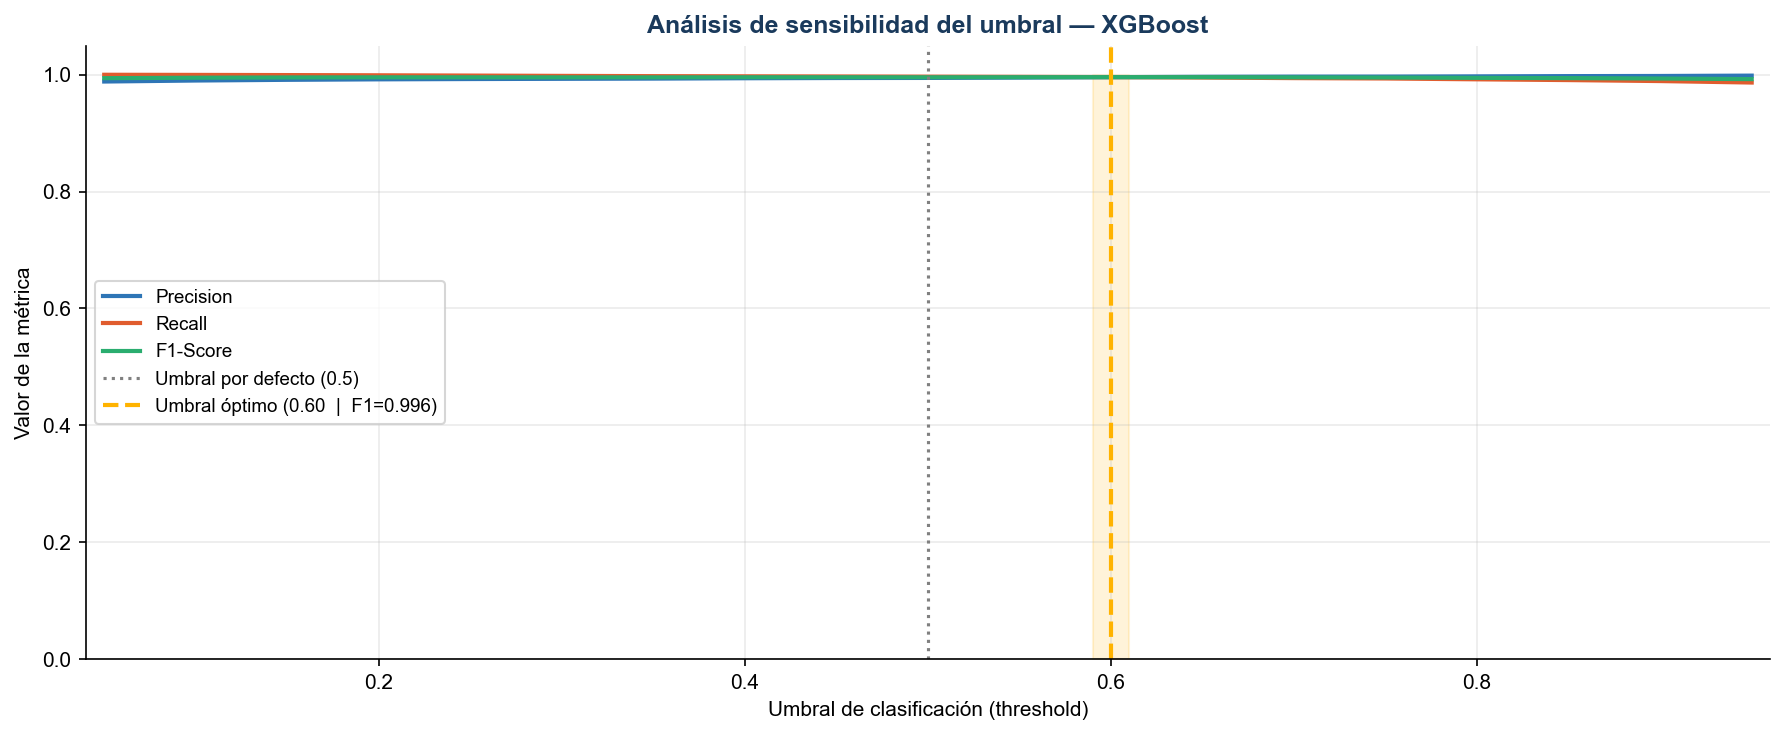

✅ Figura 24 guardada
   Umbral óptimo: 0.60  →  F1=0.996 | Precision=0.996 | Recall=0.996

📋 Copia estos valores en la Tabla 19 del Word


In [17]:
# ── CELDA 15: FIGURA 24 — Análisis de umbral ──────────────────────────────────
from sklearn.metrics import precision_recall_fscore_support
 
# Usar el mejor modelo
if mejor_nombre == "XGBoost":
    probas = res_xgb["_y_proba"]
else:
    probas = res_rf["_y_proba"] if mejor_nombre == "Random Forest" else res_rl["_y_proba"]
 
thresholds  = np.arange(0.05, 0.96, 0.05)
precisiones, recalls, f1s = [], [], []
 
for t in thresholds:
    y_pred_t = (probas >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average="binary", zero_division=0)
    precisiones.append(p)
    recalls.append(r)
    f1s.append(f)
 
idx_opt  = np.argmax(f1s)
t_opt    = thresholds[idx_opt]
f1_opt   = f1s[idx_opt]
 
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(thresholds, precisiones, color=COLOR_CORP,   linewidth=2, label="Precision")
ax1.plot(thresholds, recalls,     color="#E05C2E",    linewidth=2, label="Recall")
ax1.plot(thresholds, f1s,         color="#2AAD6F",    linewidth=2, label="F1-Score")
ax1.axvline(0.5,   color="gray",    linestyle=":",  linewidth=1.5, label="Umbral por defecto (0.5)")
ax1.axvline(t_opt, color="#FFB300", linestyle="--", linewidth=2,
            label=f"Umbral óptimo ({t_opt:.2f}  |  F1={f1_opt:.3f})")
ax1.fill_betweenx([0,1], t_opt-0.01, t_opt+0.01, alpha=0.15, color="#FFB300")
ax1.set_xlabel("Umbral de clasificación (threshold)")
ax1.set_ylabel("Valor de la métrica")
ax1.set_title(f"Análisis de sensibilidad del umbral — {mejor_nombre}",
              fontsize=12, fontweight="bold", color="#1a3a5c")
ax1.legend(fontsize=9, loc="center left")
ax1.set_xlim([0.04, 0.96])
ax1.set_ylim([0, 1.05])
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("figura24_analisis_umbral.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"✅ Figura 24 guardada")
print(f"   Umbral óptimo: {t_opt:.2f}  →  F1={f1_opt:.3f} | "
      f"Precision={precisiones[idx_opt]:.3f} | Recall={recalls[idx_opt]:.3f}")
print(f"\n📋 Copia estos valores en la Tabla 19 del Word")

In [18]:
# ── CELDA 16: TABLA 19 — Estabilidad con 10 semillas ─────────────────────────
print("\n🔄 Evaluando estabilidad del modelo con 10 semillas aleatorias...")

seeds   = list(range(10))
aucs, recs, f1s_seed = [], [], []

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed)

    if mejor_nombre == "XGBoost":
   
        preprocessor_seed = clone(preprocessor)
        X_tr_t = preprocessor_seed.fit_transform(X_tr)
        X_te_t = preprocessor_seed.transform(X_te)

        feat_names_seed = preprocessor_seed.get_feature_names_out()
        X_tr_t = pd.DataFrame(X_tr_t, columns=feat_names_seed)
        X_te_t = pd.DataFrame(X_te_t, columns=feat_names_seed)

        m = xgb.XGBClassifier(**{k.replace("clf__",""):v
                                  for k,v in gs_xgb.best_params_.items()},
                               random_state=seed, verbosity=0,
                               eval_metric="auc")
        m.fit(X_tr_t, y_tr)
        yp = m.predict(X_te_t)
        yproba = m.predict_proba(X_te_t)[:,1]
    else:
  
        base_pipe = gs_rf.best_estimator_ if mejor_nombre=="Random Forest" else gs_rl.best_estimator_
        best_pipe = clone(base_pipe)
        best_pipe.fit(X_tr, y_tr)
        yp = best_pipe.predict(X_te)
        yproba = best_pipe.predict_proba(X_te)[:,1]

    aucs.append(roc_auc_score(y_te, yproba))
    recs.append(recall_score(y_te, yp, zero_division=0))
    f1s_seed.append(f1_score(y_te, yp, zero_division=0))

def ic95(vals):
    m = np.mean(vals)
    s = np.std(vals)
    return m, s, m - 1.96*s, m + 1.96*s

print("\n" + "="*65)
print("TABLA 19 — Estabilidad del modelo (10 semillas)")
print("="*65)
for metrica, vals in [("AUC-ROC", aucs), ("Recall", recs), ("F1-Score", f1s_seed)]:
    m, s, lo, hi = ic95(vals)
    print(f"  {metrica:<12}: Media={m:.4f}  Desv={s:.4f}  "
          f"Mín={min(vals):.4f}  Máx={max(vals):.4f}  IC95=[{lo:.4f},{hi:.4f}]")
print(f"\n✅ Copia estos valores en la Tabla 19 del documento Word")
print(f"\n✅ El preprocessor y los modelos originales (gs_rl, gs_rf, gs_xgb)")
print(f"   permanecen intactos: este bloque solo usó copias temporales (clone).")



🔄 Evaluando estabilidad del modelo con 10 semillas aleatorias...

TABLA 19 — Estabilidad del modelo (10 semillas)
  AUC-ROC     : Media=0.9916  Desv=0.0016  Mín=0.9881  Máx=0.9937  IC95=[0.9883,0.9948]
  Recall      : Media=0.9971  Desv=0.0004  Mín=0.9962  Máx=0.9976  IC95=[0.9963,0.9980]
  F1-Score    : Media=0.9958  Desv=0.0003  Mín=0.9954  Máx=0.9962  IC95=[0.9952,0.9964]

✅ Copia estos valores en la Tabla 19 del documento Word

✅ El preprocessor y los modelos originales (gs_rl, gs_rf, gs_xgb)
   permanecen intactos: este bloque solo usó copias temporales (clone).


In [19]:
# ── CELDA 17: TABLA 20 — Resumen ejecutivo ────────────────────────────────────
mejor_res = {"RL": res_rl, "RF": res_rf, "XGB": res_xgb}[
    {"Regresión Logística":"RL","Random Forest":"RF","XGBoost":"XGB"}[mejor_nombre]]
 
m_auc, _, _, _ = ic95(aucs)
 
print("\n" + "="*65)
print("TABLA 20 — Resumen ejecutivo para la gerencia de VLR México")
print("="*65)
print(f"  Mejor modelo:              {mejor_nombre}")
print(f"  AUC-ROC (test holdout):    {mejor_res['AUC-ROC']:.4f}")
print(f"  AUC-ROC promedio (10 CV):  {m_auc:.4f}")
print(f"  Recall (clase rechazada):  {mejor_res['Recall']:.4f}")
print(f"  F1-Score:                  {mejor_res['F1-Score']:.4f}")
print(f"  Precision:                 {mejor_res['Precision']:.4f}")
print(f"  Umbral óptimo recomendado: {t_opt:.2f}")
print(f"  Recall con umbral óptimo:  {recalls[idx_opt]:.4f}")
print(f"  Precision con umbral opt.: {precisiones[idx_opt]:.4f}")
 
top3 = df_imp.sort_values("Importancia", ascending=False).head(3)
print(f"\n  Top 3 variables de riesgo:")
for _, row in top3.iterrows():
    print(f"    → {row['Feature']:<30} Importancia: {row['Importancia']:.4f}")


TABLA 20 — Resumen ejecutivo para la gerencia de VLR México
  Mejor modelo:              XGBoost
  AUC-ROC (test holdout):    0.9913
  AUC-ROC promedio (10 CV):  0.9916
  Recall (clase rechazada):  0.9966
  F1-Score:                  0.9956
  Precision:                 0.9945
  Umbral óptimo recomendado: 0.60
  Recall con umbral óptimo:  0.9959
  Precision con umbral opt.: 0.9958

  Top 3 variables de riesgo:
    → BODY_PILLOW_REPAIR/SAMPLE      Importancia: 0.5996
    → SEMANA_NUM                     Importancia: 0.1154
    → EFIC_PREP                      Importancia: 0.1036


In [20]:
# ── CELDA 18: Guardar modelos entrenados ──────────────────────────────────────
import joblib
import os

os.makedirs("modelos", exist_ok=True)

# Modelos que ya son Pipelines completos (preprocessor + clasificador):
# se pueden usar directamente con .predict_proba(X_crudo)
joblib.dump(gs_rl.best_estimator_, "modelos/modelo_rl.pkl")
joblib.dump(gs_rf.best_estimator_, "modelos/modelo_rf.pkl")


pipeline_xgb_completo = Pipeline([
    ("pre", preprocessor),
    ("clf", gs_xgb.best_estimator_),
])

# Verificación de que el pipeline combinado reproduce las mismas
# predicciones que el flujo manual preprocessor+modelo usado durante
# el entrenamiento, antes de guardarlo.
proba_manual    = gs_xgb.best_estimator_.predict_proba(X_test_t)[:, 1]
proba_pipeline  = pipeline_xgb_completo.predict_proba(X_test)[:, 1]
diff_max = np.abs(proba_manual - proba_pipeline).max()
assert diff_max < 1e-9, (
    f"❌ El pipeline combinado NO reproduce las predicciones originales "
    f"(diff máxima = {diff_max}). No se guardará para evitar publicar "
    f"un modelo inconsistente."
)
print(f"✅ Pipeline combinado verificado: diferencia máxima = {diff_max:.2e}")

joblib.dump(pipeline_xgb_completo, "modelos/pipeline_xgb_completo.pkl")


joblib.dump(gs_xgb.best_estimator_, "modelos/modelo_xgb.pkl")
joblib.dump(preprocessor,           "modelos/preprocessor.pkl")

print("\n✅ Modelos guardados en carpeta 'modelos/':")
for f in os.listdir("modelos"):
    size = os.path.getsize(f"modelos/{f}") / 1024
    print(f"   {f:<35} {size:>8.1f} KB")

print("\n📌 RECOMENDACIÓN: usar 'pipeline_xgb_completo.pkl' en el dashboard")
print("   en lugar de cargar 'modelo_xgb.pkl' + 'preprocessor.pkl' por separado.")


✅ Pipeline combinado verificado: diferencia máxima = 0.00e+00

✅ Modelos guardados en carpeta 'modelos/':
   .gitkeep                                 0.0 KB
   modelo_rf.pkl                        31687.1 KB
   modelo_rl.pkl                          354.3 KB
   modelo_xgb.pkl                        1170.8 KB
   pipeline_xgb_completo.pkl             1425.1 KB
   preprocessor.pkl                       254.3 KB

📌 RECOMENDACIÓN: usar 'pipeline_xgb_completo.pkl' en el dashboard
   en lugar de cargar 'modelo_xgb.pkl' + 'preprocessor.pkl' por separado.


In [21]:
# ── CELDA 19: Resumen de figuras generadas ────────────────────────────────────
import glob
figuras = sorted(glob.glob("figura*.png"))
print("\n" + "="*55)
print("📁 FIGURAS DEL CAPÍTULO 5 GENERADAS")
print("="*55)
for f in figuras:
    size = os.path.getsize(f) / 1024
    print(f"  {f:<42} {size:>6.1f} KB")
 
print(f"\n✅ {len(figuras)} figuras listas para insertar en el documento Word")
print("   → Haz doble clic en cada cuadro [IMAGEN] del documento")
print("   → Selecciona la figura PNG correspondiente")


📁 FIGURAS DEL CAPÍTULO 5 GENERADAS
  figura14_balance_clases.png                  86.5 KB
  figura17_division_dataset.png                61.0 KB
  figura19_curvas_roc_pr.png                  131.2 KB
  figura20_matrices_confusion.png              86.5 KB
  figura21_importancia_variables.png          102.5 KB
  figura22_shap_beeswarm.png                  117.9 KB
  figura23_shap_waterfall.png                 135.5 KB
  figura24_analisis_umbral.png                 63.0 KB

✅ 8 figuras listas para insertar en el documento Word
   → Haz doble clic en cada cuadro [IMAGEN] del documento
   → Selecciona la figura PNG correspondiente


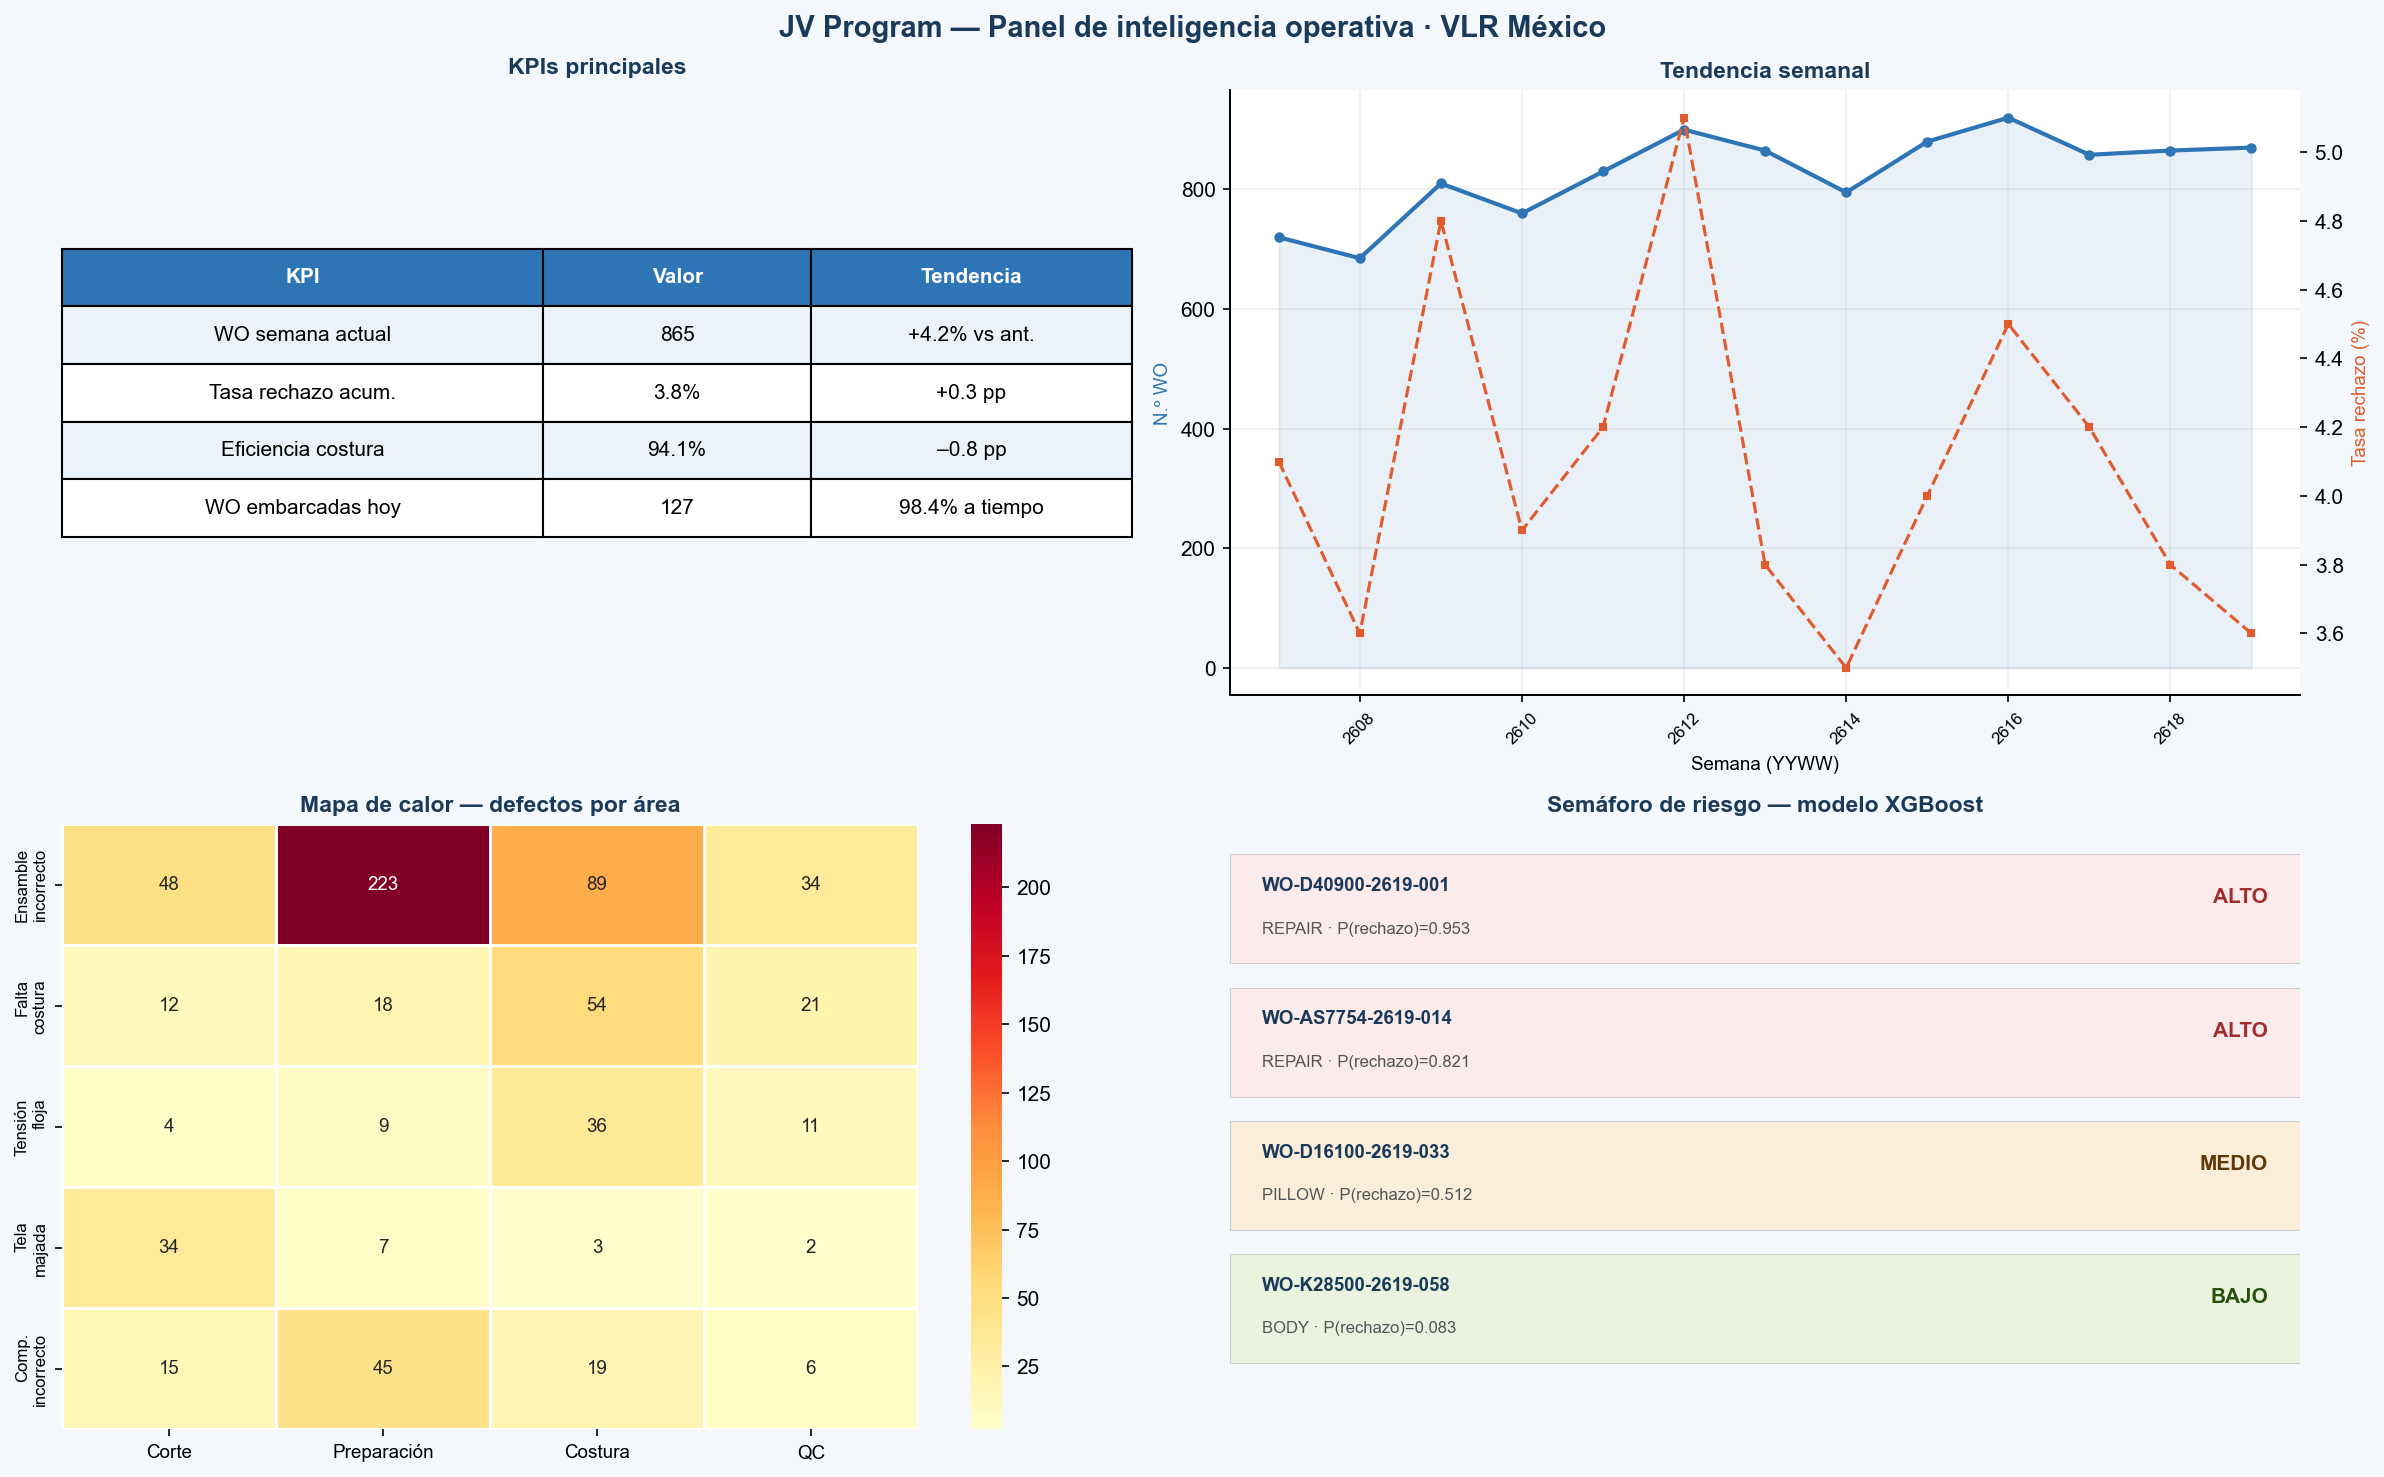

✅ Figura 21 guardada: figura21_dashboard_mockup.png


In [22]:
# Generar mockup del dashboard como figura para el Word
# (versión estática con matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#F4F8FC')
fig.suptitle("JV Program — Panel de inteligencia operativa · VLR México",
             fontsize=14, fontweight="bold", color="#1a3a5c", y=0.98)

# Panel 1: KPIs como tabla
axes[0,0].axis("off")
kpis = [["WO semana actual","865","+4.2% vs ant."],
        ["Tasa rechazo acum.","3.8%","+0.3 pp"],
        ["Eficiencia costura","94.1%","–0.8 pp"],
        ["WO embarcadas hoy","127","98.4% a tiempo"]]
tbl = axes[0,0].table(cellText=kpis, colLabels=["KPI","Valor","Tendencia"],
                       cellLoc="center", loc="center",
                       colWidths=[0.45,0.25,0.3])
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1,2)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor("#2E75B6"); cell.set_text_props(color="white",fontweight="bold")
    elif r % 2: cell.set_facecolor("#EAF3FB")
axes[0,0].set_title("KPIs principales", fontsize=11, fontweight="bold", color="#1a3a5c", pad=8)

# Panel 2: Tendencia semanal
semanas = list(range(2607, 2620))
wo_data = [720,685,810,760,830,900,865,795,880,920,858,865,870]
tasa_data = [4.1,3.6,4.8,3.9,4.2,5.1,3.8,3.5,4.0,4.5,4.2,3.8,3.6]
ax2b = axes[0,1].twinx()
axes[0,1].plot(semanas, wo_data, color="#2E75B6", linewidth=2, marker="o", markersize=4, label="WO activas")
axes[0,1].fill_between(semanas, wo_data, alpha=0.1, color="#2E75B6")
ax2b.plot(semanas, tasa_data, color="#E05C2E", linewidth=1.5, linestyle="--", marker="s", markersize=3, label="Tasa rechazo (%)")
axes[0,1].set_title("Tendencia semanal", fontsize=11, fontweight="bold", color="#1a3a5c")
axes[0,1].set_xlabel("Semana (YYWW)", fontsize=9)
axes[0,1].tick_params(axis="x", rotation=45, labelsize=8)
axes[0,1].set_ylabel("N.º WO", color="#2E75B6", fontsize=9)
ax2b.set_ylabel("Tasa rechazo (%)", color="#E05C2E", fontsize=9)
axes[0,1].grid(alpha=0.2)

# Panel 3: Mapa de calor
import numpy as np
defectos = ["Ensamble\nincorrecto","Falta\ncostura","Tensión\nfloja","Tela\nmajada","Comp.\nincorrecto"]
areas = ["Corte","Preparación","Costura","QC"]
heat = np.array([[48,223,89,34],[12,18,54,21],[4,9,36,11],[34,7,3,2],[15,45,19,6]])
sns.heatmap(heat, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=areas, yticklabels=defectos,
            ax=axes[1,0], linewidths=0.5, annot_kws={"size":9})
axes[1,0].set_title("Mapa de calor — defectos por área", fontsize=11, fontweight="bold", color="#1a3a5c")
axes[1,0].tick_params(axis="x", labelsize=9)
axes[1,0].tick_params(axis="y", labelsize=8)

# Panel 4: Semáforo de riesgo
axes[1,1].axis("off")
wo_riesgo = [["WO-D40900-2619-001","REPAIR","0.953","ALTO"],
             ["WO-AS7754-2619-014","REPAIR","0.821","ALTO"],
             ["WO-D16100-2619-033","PILLOW","0.512","MEDIO"],
             ["WO-K28500-2619-058","BODY"  ,"0.083","BAJO"]]
colores_riesgo = {"ALTO":"#FCEBEB","MEDIO":"#FAEEDA","BAJO":"#EAF3DE"}
for i, (wo_id, tipo, prob, nivel) in enumerate(wo_riesgo):
    y_pos = 0.85 - i * 0.22
    color_fondo = colores_riesgo[nivel]
    axes[1,1].add_patch(plt.Rectangle((0, y_pos-0.08), 1, 0.18,
                         facecolor=color_fondo, edgecolor="#cccccc",
                         linewidth=0.5, transform=axes[1,1].transAxes))
    axes[1,1].text(0.03, y_pos+0.04, wo_id, transform=axes[1,1].transAxes,
                   fontsize=9, fontweight="bold", color="#1a3a5c")
    axes[1,1].text(0.03, y_pos-0.03, f"{tipo} · P(rechazo)={prob}",
                   transform=axes[1,1].transAxes, fontsize=8, color="#555")
    tc = {"ALTO":"#A32D2D","MEDIO":"#633806","BAJO":"#27500A"}[nivel]
    axes[1,1].text(0.97, y_pos+0.02, nivel, transform=axes[1,1].transAxes,
                   fontsize=10, fontweight="bold", color=tc, ha="right")
axes[1,1].set_title("Semáforo de riesgo — modelo XGBoost", fontsize=11, fontweight="bold", color="#1a3a5c")

plt.tight_layout()
plt.savefig("figura21_dashboard_mockup.png", dpi=150,
            bbox_inches="tight", facecolor="#F4F8FC")
plt.show()
print("✅ Figura 21 guardada: figura21_dashboard_mockup.png")